In [83]:
import matplotlib.pyplot as plt
from pydrawnet.renderers import SeqRenderer
from pydrawnet import layers, operations
from matplotlib.patches import Rectangle

In [194]:
labels = {
    "input": "Input\n128x128x3",
    "conv": "Conv2d",
    "norm": "BatchNorm",
    "pool": "MaxPool",
    "relu": "ReLU",
    "sigmoid": "Sigmoid",
    "output": "Output",
}

colors = {
    labels["conv"]: (1.0, 0.5, 0.0),  # arancione
    labels["input"]: (0.1, 0.1, 0.1),  # dark gray almost black
    labels["pool"]: (0.0, 0.0, 0.9),
    labels["norm"]: (0.0, 0.9, 0.0),  # green
    labels["relu"]: (1.0, 0.0, 0.0),  # red
    labels["sigmoid"]: (1.0, 1.0, 0.0),  # giallo
}

colors

{'Conv2d': (1.0, 0.5, 0.0),
 'Input\n128x128x3': (0.1, 0.1, 0.1),
 'MaxPool': (0.0, 0.0, 0.9),
 'BatchNorm': (0.0, 0.9, 0.0),
 'ReLU': (1.0, 0.0, 0.0),
 'Sigmoid': (1.0, 1.0, 0.0)}

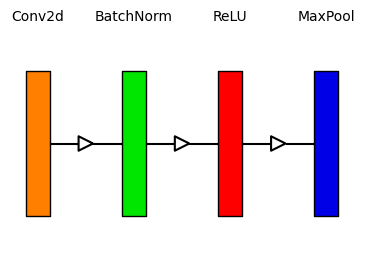

In [195]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 3)
axs = fig.axes

SR1 = SeqRenderer(axs[0])

conv_pool = [
    labels["conv"],
    labels["norm"],
    labels["relu"],
    labels["pool"],
]

for i, L in enumerate(conv_pool):
    SR1.add_layer(layers.BlockLayer(5, 30, label=L, fill_color=colors[L]))
    if i < len(conv_pool) - 1:
        SR1.add_operation(operations.ArrowOp("", 3))

SR1.render(10)

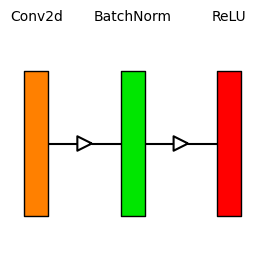

In [196]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 3)
axs = fig.axes


SR2 = SeqRenderer(axs[0])

conv_no_pool = [
    labels["conv"],
    labels["norm"],
    labels["relu"],
]

for i, L in enumerate(conv_no_pool):
    SR2.add_layer(layers.BlockLayer(5, 30, label=L, fill_color=colors[L]))
    if i < len(conv_no_pool) - 1:
        SR2.add_operation(operations.ArrowOp("", 3))

SR2.render(10)

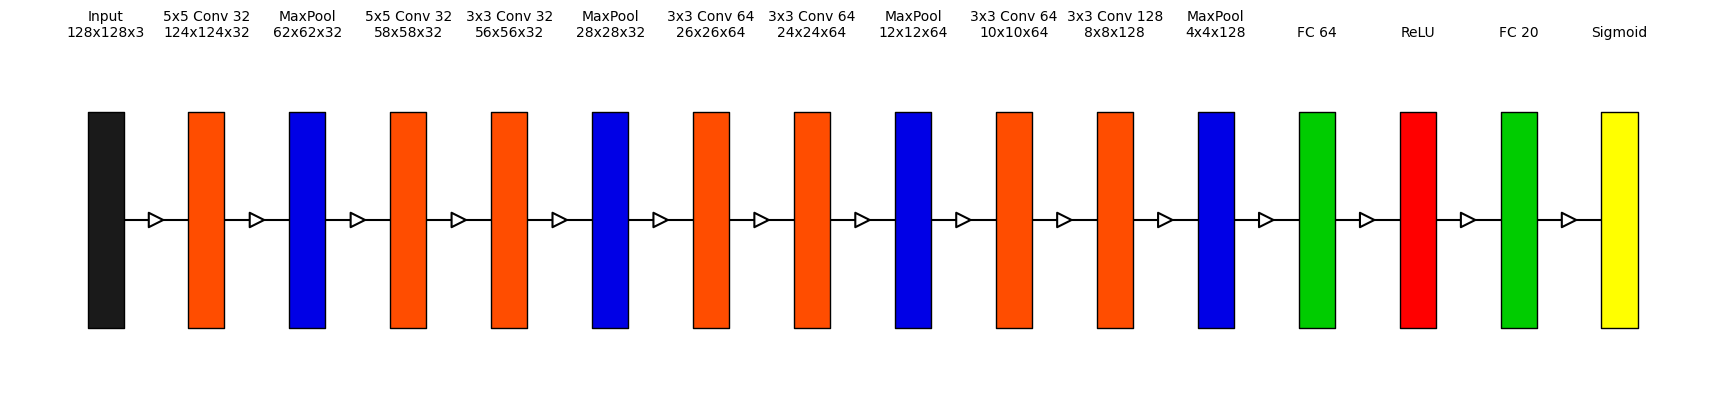

In [193]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(22, 10)
axs = fig.axes


SR = SeqRenderer(axs[0])

conv_no_pool = [
    labels["input"],
    "5x5 Conv 32\n124x124x32",
    labels["pool"] + "\n62x62x32",
    "5x5 Conv 32\n58x58x32",
    "3x3 Conv 32\n56x56x32",
    labels["pool"] + "\n28x28x32",
    "3x3 Conv 64\n26x26x64",
    "3x3 Conv 64\n24x24x64",
    labels["pool"] + "\n12x12x64",
    "3x3 Conv 64\n10x10x64",
    "3x3 Conv 128\n8x8x128",
    labels["pool"] + "\n4x4x128",
    "FC 64",
    labels["relu"],
    "FC 20",
    labels["sigmoid"],
]

# Set colors for blocks that don't have one
for block in conv_no_pool:
    if block not in colors:
        if "Conv" in block:
            colors[block] = (1.0, 0.3, 0.0)
        elif "FC" in block:
            colors[block] = (0.0, 0.8, 0.0)
        elif "Pool" in block:
            colors[block] = colors[labels["pool"]]

for i, L in enumerate(conv_no_pool):
    SR.add_layer(layers.BlockLayer(5, 30, label=L, fill_color=colors[L]))
    if i < len(conv_no_pool) - 1:
        SR.add_operation(operations.ArrowOp("", 2))

SR.render(6)

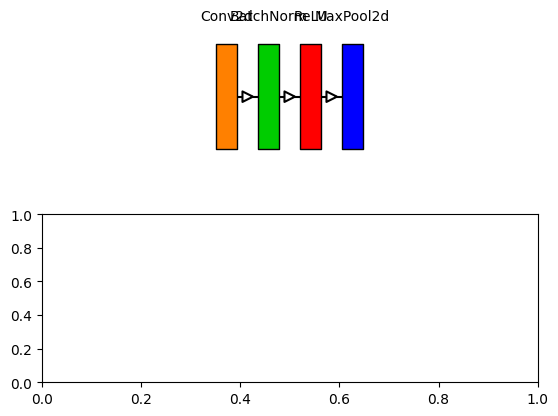

In [57]:
fig, ax = plt.subplots(2, 1)

SR = SeqRenderer(ax[0])
arrow_length = 5
for i, L in enumerate(conv_block):
    SR.add_layer(layers.BlockLayer(10, 50, label=L, fill_color=colors[L]))
    if i < len(conv_block) - 1:
        SR.add_operation(operations.ArrowOp("", arrow_length))
SR.render(10)

SR1 = SeqRenderer(ax[1])
arrow_length = 5
for i, L in enumerate(conv_block):
    SR1.add_layer(layers.BlockLayer(10, 50, label=L, fill_color=colors[L]))
    if i < len(conv_block) - 1:
        SR1.add_operation(operations.ArrowOp("", arrow_length))
SR1.render(10)